🔍 Sélectionnez votre fichier Excel ou CSV à analyser:


FileChooser(path='\\10.69.168.1\crnldata\forgetting\Carla', filename='', title='<b>Sélectionnez votre fichier …

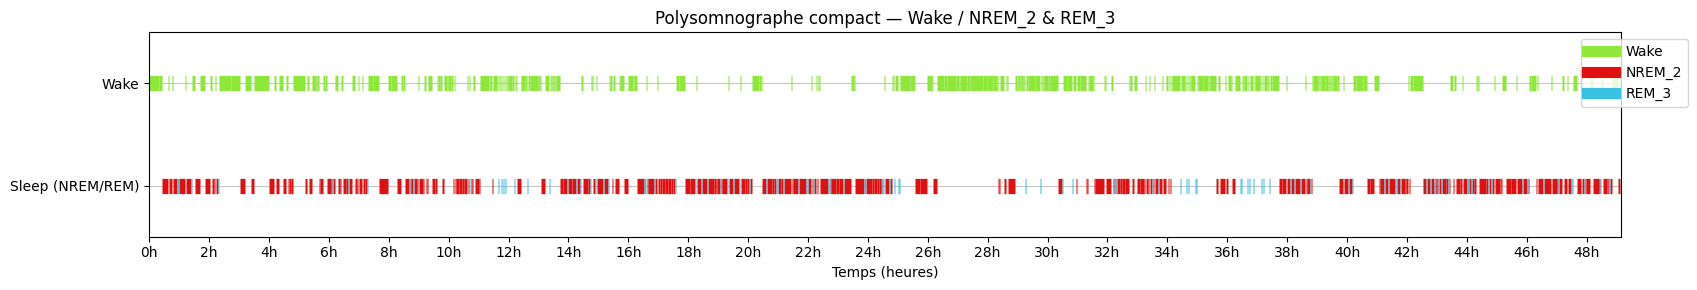

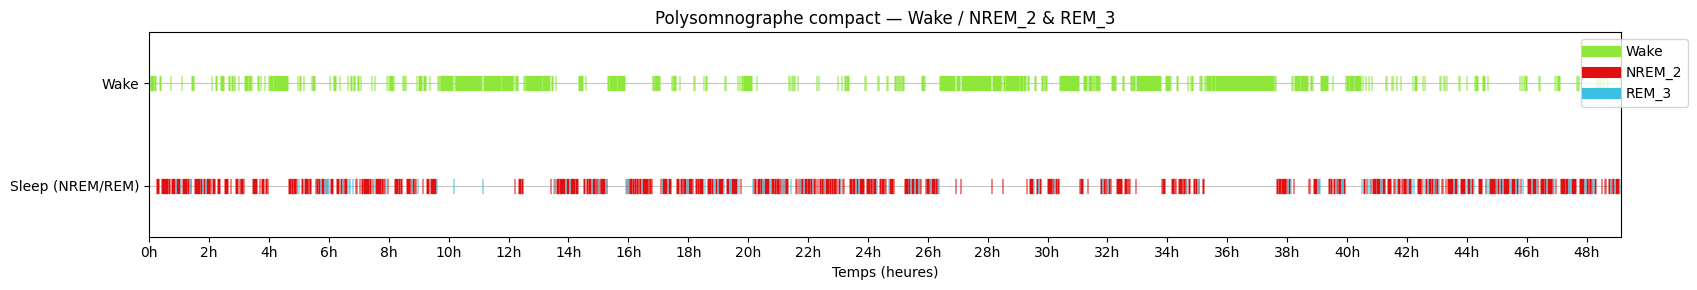

In [1]:
# === Imports ===
import os
import pandas as pd
import matplotlib.pyplot as plt
from ipyfilechooser import FileChooser
from IPython.display import display
from matplotlib.lines import Line2D

# === Dossier de départ ===
dpath = "//10.69.168.1/crnldata/forgetting/Carla/"
print("🔍 Sélectionnez votre fichier Excel ou CSV à analyser:")

# Sélecteur de fichier
fc1 = FileChooser(
    dpath,
    filter_pattern=['*.xlsx', '*.csv'],
    title="<b>Sélectionnez votre fichier Excel/CSV à analyser</b>"
)
display(fc1)

# === Callback pour traiter le fichier choisi ===
def update_file(chooser):
    global fichier_choisi, dpath
    fichier_choisi = chooser.selected
    dpath = os.path.dirname(fichier_choisi)
    get_ipython().run_line_magic('store', 'dpath')
    print(f"✅ Fichier sélectionné: {os.path.basename(fichier_choisi)}")
    
    # === Lecture du fichier ===
    if fichier_choisi.endswith(".csv"):
        df = pd.read_csv(fichier_choisi, sep=',')  # Ajout du séparateur ;
    else:
        df = pd.read_excel(fichier_choisi)
    
    print(f"\n📊 Aperçu des données:")
    print(df.head())
    print(f"\nNombre d'épisodes: {len(df)}")
    
    # === Les colonnes sont déjà en secondes (start_time, end_time) ===
    # Pas besoin de conversion
    
    # === Couleurs et positions verticales ===
    colors = {
        "Wake_1": "#8FE73C",  # vert clair
        "NREM_2": "#E01010",  # rouge
        "REM_3":  "#39C0E2",  # bleu
    }
    y_positions = {"Wake_1": 1.0, "Sleep": 0.0}
    
    fig, ax = plt.subplots(figsize=(17, 3))
    linewidth = 11  # largeur des lignes
    
    # --- Wake ---
    for _, row in df[df["label"] == "Wake_1"].iterrows():
        ax.plot([row["start_time"], row["end_time"]],
                [y_positions["Wake_1"], y_positions["Wake_1"]],
                color=colors["Wake_1"], linewidth=linewidth, solid_capstyle="butt", alpha=1)
    
    # --- Sleep : NREM_2 + REM_3 ---
    for lbl in ["NREM_2", "REM_3"]:
        for _, row in df[df["label"] == lbl].iterrows():
            ax.plot([row["start_time"], row["end_time"]],
                    [y_positions["Sleep"], y_positions["Sleep"]],
                    color=colors[lbl], linewidth=linewidth, solid_capstyle="butt", alpha=1)
    
    # === Mise en forme ===
    ax.set_yticks([y_positions["Wake_1"], y_positions["Sleep"]])
    ax.set_yticklabels(["Wake", "Sleep (NREM/REM)"])
    ax.set_xlabel("Temps (heures)")
    ax.set_title("Polysomnographe compact — Wake / NREM_2 & REM_3")
    ax.grid(True, axis="y", alpha=0.7)
    
    # === Axe X en heures, ticks toutes les 2 heures ===
    max_time = df["end_time"].max()
    hours = range(0, int(max_time // 3600) + 2, 2)
    ax.set_xticks([h*3600 for h in hours])
    ax.set_xticklabels([f"{h}h" for h in hours])
    
    ax.set_xlim(0, max_time + 60)  # padding 1 min
    ax.set_ylim(-0.5, 1.5)
    
    # === Légende ===
    legend_elements = [
        Line2D([0], [0], color=colors["Wake_1"], lw=8, label="Wake"),
        Line2D([0], [0], color=colors["NREM_2"], lw=8, label="NREM_2"),
        Line2D([0], [0], color=colors["REM_3"], lw=8, label="REM_3"),
    ]
    ax.legend(bbox_to_anchor=(1.05, 1), handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.show()
    
    # === Enregistrement dans le même dossier que le fichier choisi ===
    folder = os.path.dirname(fichier_choisi)
    output_file = os.path.join(folder, "Hypnogramme.png")
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Figure enregistrée : {output_file}")

# Enregistrer le callback
fc1.register_callback(update_file)
